In [6]:
# Import necessary packages
import seaborn as sns
import numpy, scipy, IPython.display as ipd 
import matplotlib.pyplot as plt
import librosa, librosa.display
plt.rcParams['figure.figsize'] = (14, 5)

# Pitch Transcription Exercise

# Load an audio file.

filename = "data/Herpai_Julia_eso_24.wav"
x, sr = librosa.load(filename)

# Play the audio file.
ipd.Audio(x, rate=sr)

C:\Users\Nagy Sándor Imre\AppData\Local\Temp\ipykernel_16264\3687949109.py:4: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  log_cqt = librosa.amplitude_to_db(cqt)


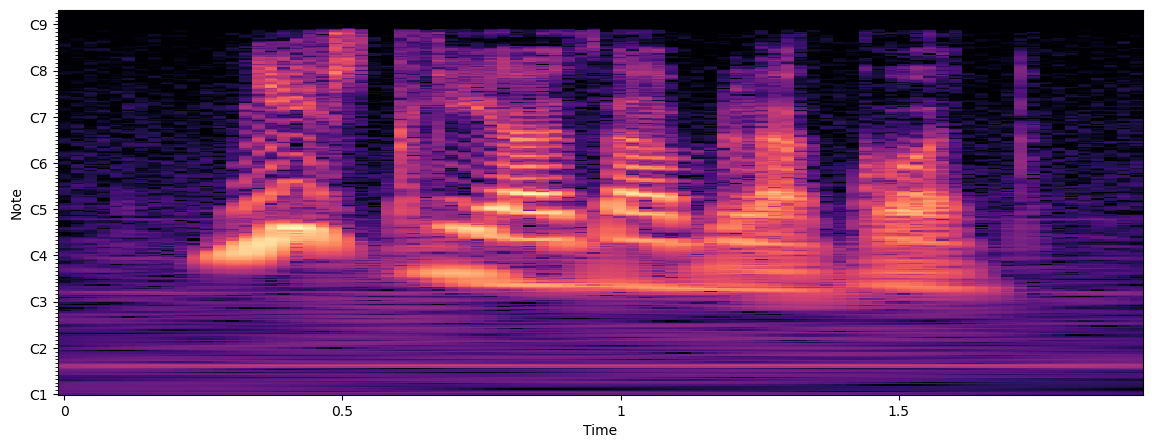

In [7]:
# Display the CQT of the signal.
bins_per_octave = 36
cqt = librosa.cqt(x, sr=sr, n_bins=300, bins_per_octave=bins_per_octave)
log_cqt = librosa.amplitude_to_db(cqt)

cqt.shape

librosa.display.specshow(log_cqt, sr=sr, x_axis='time', y_axis='cqt_note',
                         bins_per_octave=bins_per_octave)


*Goal*: Identify the pitch of each note and replace each note with a pure tone of that pitch.

## Step 1: Detect Onsets


(0.0, 428.0)

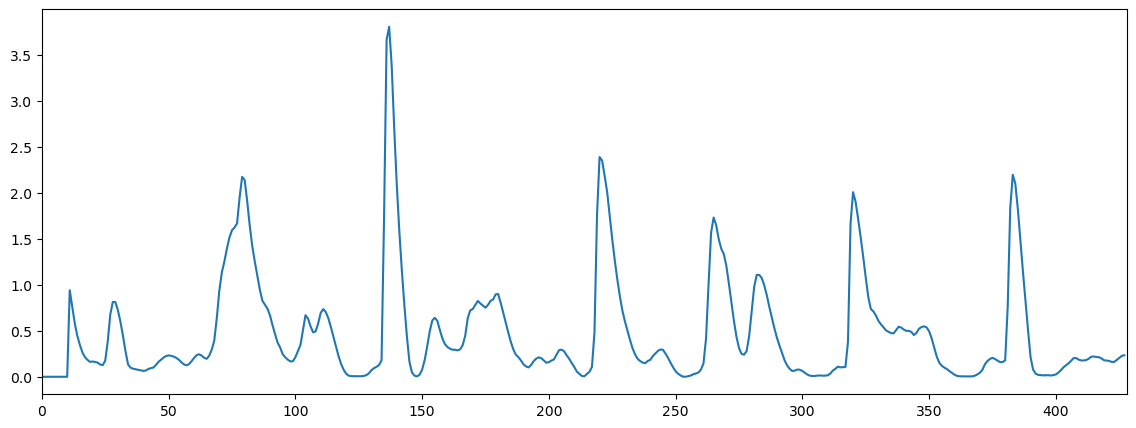

In [8]:
# To accurately detect onsets, it may be helpful to see what the novelty function looks like:
hop_length = 100
onset_env = librosa.onset.onset_strength(y=x, sr=sr, hop_length=hop_length)

plt.plot(onset_env)
plt.xlim(0, len(onset_env))

Among the obvious large peaks, there are many smaller peaks. We want to choose parameters which preserve the large peaks while ignoring the small peaks.

Next, we try to detect onsets. For more details, see [`librosa.onset.onset_detect`](http://librosa.github.io/librosa/generated/librosa.onset.onset_detect.html#librosa.onset.onset_detect) and [`librosa.util.peak_pick`](http://librosa.github.io/librosa/generated/librosa.util.peak_pick.html#librosa.util.peak_pick).

In [9]:
onset_samples = librosa.onset.onset_detect(y=x,
                                           sr=sr, units='samples',
                                           hop_length=hop_length,
                                           backtrack=False,
                                           pre_max=20,
                                           post_max=20,
                                           pre_avg=100,
                                           post_avg=100,
                                           delta=0.2,
                                           wait=0)

onset_samples

array([ 7900, 13700, 22000, 26500, 32000, 38300])

In [10]:
# Let's pad the onsets with the beginning and end of the signal.
onset_boundaries = numpy.concatenate([[0], onset_samples, [len(x)]])

print(onset_boundaries)

[    0  7900 13700 22000 26500 32000 38300 42729]


In [11]:
# Convert the onsets to units of seconds:
onset_times = librosa.samples_to_time(onset_boundaries, sr=sr)

onset_times

array([0.        , 0.35827664, 0.62131519, 0.99773243, 1.20181406,
       1.45124717, 1.73696145, 1.93782313])

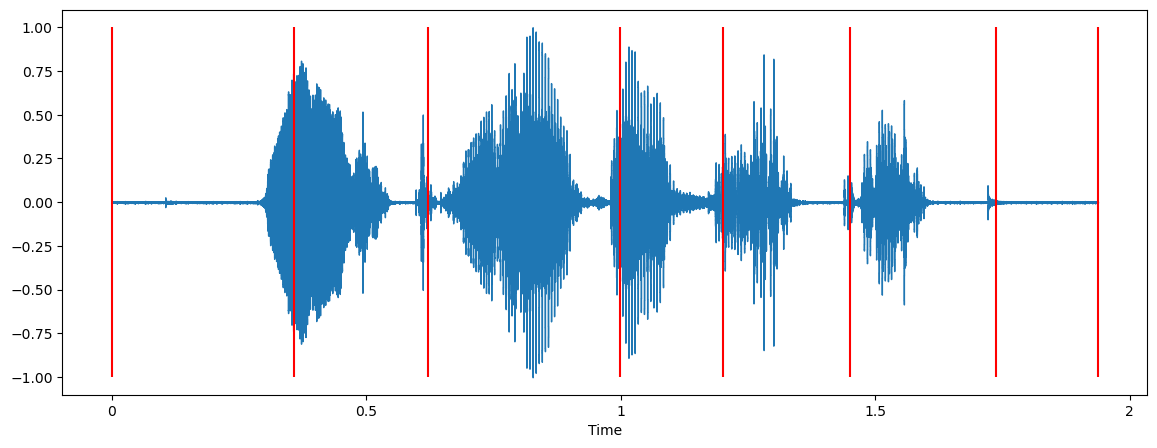

In [12]:
# Display the results of the onset detection:

librosa.display.waveshow(y=x, sr=sr)
plt.vlines(onset_times, -1, 1, color='r')

## Step 2: Estimate Pitch

Estimate pitch using the autocorrelation method:

In [13]:
def estimate_pitch(segment, sr, fmin=50.0, fmax=2000.0):

    # Compute autocorrelation of input segment.
    r = librosa.autocorrelate(segment)

    # Define lower and upper limits for the autocorrelation argmax.
    i_min = sr/fmax
    i_max = sr/fmin
    r[:int(i_min)] = 0
    r[int(i_max):] = 0

    # Find the location of the maximum autocorrelation.
    i = r.argmax()
    f0 = float(sr)/i
    return f0

## Step 3: Generate Pure Tone

In [14]:
# Create a function to generate a pure tone at the specified frequency:
def generate_sine(f0, sr, n_duration):
    n = numpy.arange(n_duration)
    return 0.2*numpy.sin(2*numpy.pi*f0*n/float(sr))

## Step 4: Put it together

In [15]:
# Create a helper function for use in a list comprehension:

def estimate_pitch_and_generate_sine(x, onset_samples, i, sr):
    n0 = onset_samples[i]
    n1 = onset_samples[i+1]
    f0 = estimate_pitch(x[n0:n1], sr)
    return generate_sine(f0, sr, n1-n0)

In [16]:
#Use a list comprehension to concatenate the synthesized segments:
y = numpy.concatenate([
    estimate_pitch_and_generate_sine(x, onset_boundaries, i, sr=sr)
    for i in range(len(onset_boundaries)-1)
])


In [17]:
# Play the synthesized transcription.

ipd.Audio(y, rate=sr)

In [18]:
ipd.Audio(x, rate=sr)

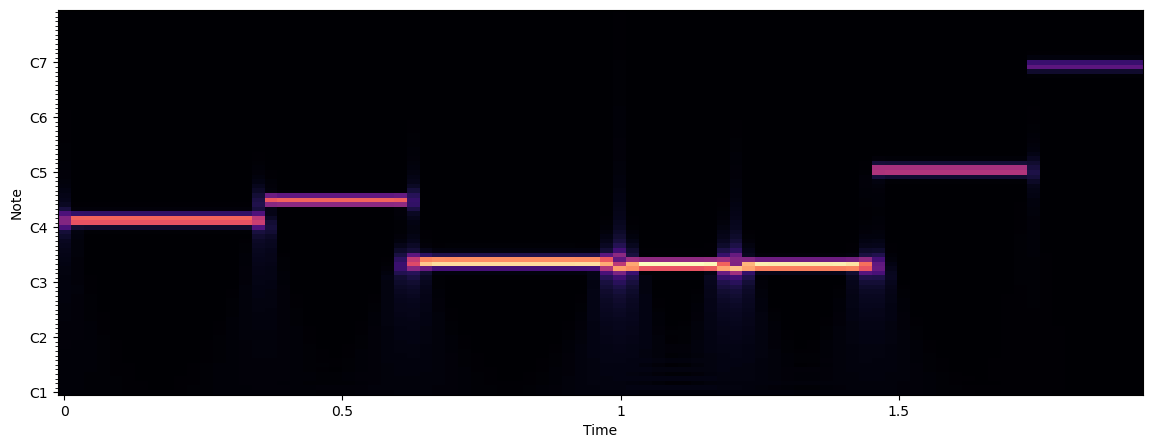

In [19]:



# Plot the CQT of the synthesized transcription.

cqt = librosa.cqt(y, sr=sr)

librosa.display.specshow(abs(cqt), sr=sr, x_axis='time', y_axis='cqt_note')